# Visualización de Resultados de Evaluación del Motor de Consultas

Este notebook permite visualizar de forma interactiva los resultados de la evaluación del SmartNeo4jEngine.

## Contenido
1. Carga de resultados
2. Análisis de métricas generales
3. Análisis por categoría
4. Visualización de Cypher queries generadas
5. Análisis de tiempos de ejecución

In [27]:
# Importar librerías necesarias
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurar estilo de las gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Carga de Resultados

In [28]:
# Cargar resultados de evaluación
with open('evaluation_results_flash.json', 'r', encoding='utf-8') as f:
    results = json.load(f)

# Mostrar metadata
print("="*80)
print("📊 METADATOS DE LA EVALUACIÓN")
print("="*80)
print(f"Fecha: {results['metadata']['timestamp']}")
print(f"Modelo LLM: {results['metadata']['model']}")
print(f"Modelo de Embeddings: {results['metadata']['embedding_model']}")
print(f"Base de datos: {results['metadata']['neo4j_url']}")
print()

📊 METADATOS DE LA EVALUACIÓN
Fecha: 2025-11-27T23:04:23.569142
Modelo LLM: models/gemini-2.5-flash
Modelo de Embeddings: models/text-embedding-004
Base de datos: neo4j+s://ce30717d.databases.neo4j.io



## 2. Métricas Generales

In [29]:
# Resumen general
summary = results['summary']

print("="*80)
print("🎯 RESUMEN GENERAL")
print("="*80)
print(f"Total de pruebas:                {summary['total_tests']}")
print(f"Pruebas exitosas:                {summary['successful']} ✅")
print(f"Pruebas fallidas:                {summary['failed']} ❌")
print(f"Tasa de éxito:                   {summary['success_rate']*100:.1f}%")
print(f"Tiempo promedio de ejecución:    {summary['avg_execution_time']:.3f}s")
print(f"Intentos promedio (auto-correc): {summary['avg_attempts']:.2f}")
print()

🎯 RESUMEN GENERAL
Total de pruebas:                13
Pruebas exitosas:                11 ✅
Pruebas fallidas:                2 ❌
Tasa de éxito:                   84.6%
Tiempo promedio de ejecución:    3.598s
Intentos promedio (auto-correc): 1.15



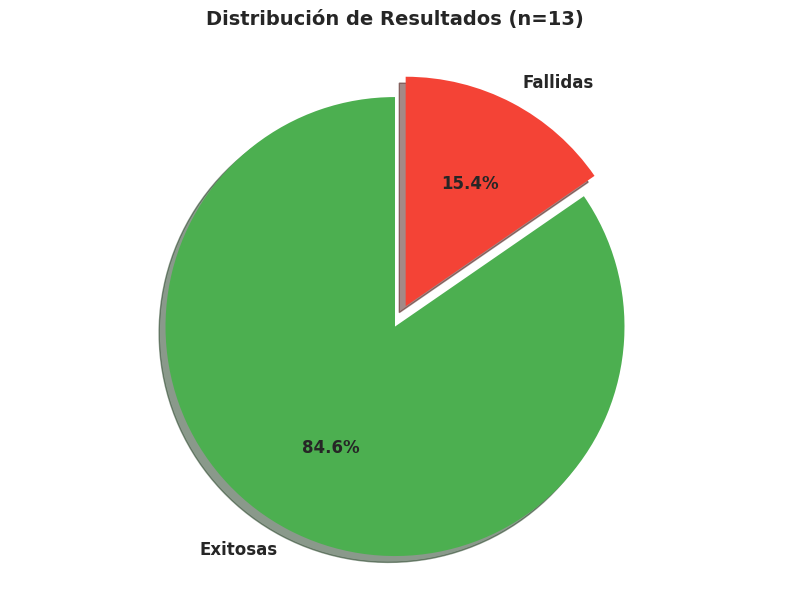

In [30]:
# Gráfico de pastel - Distribución de éxito/fallo
fig, ax = plt.subplots(figsize=(8, 6))

labels = ['Exitosas', 'Fallidas']
sizes = [summary['successful'], summary['failed']]
colors = ['#4CAF50', '#F44336']
explode = (0.1, 0)

ax.pie(sizes, explode=explode, labels=labels, colors=colors,
       autopct='%1.1f%%', shadow=True, startangle=90,
       textprops={'fontsize': 12, 'weight': 'bold'})
ax.axis('equal')
ax.set_title(f'Distribución de Resultados (n={summary["total_tests"]})',
            fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 3. Análisis por Categoría

In [31]:
# Mostrar métricas por categoría
categories = results['by_category']

print("="*80)
print("📂 RESULTADOS POR CATEGORÍA")
print("="*80)

for cat, metrics in categories.items():
    print(f"\n{cat.upper()}")
    print(f"  Total de pruebas:     {metrics['total']}")
    print(f"  Pruebas exitosas:     {metrics['success']}/{metrics['total']} ({metrics['success_rate']*100:.1f}%)")
    print(f"  Tiempo promedio:      {metrics['avg_time']:.3f}s")

📂 RESULTADOS POR CATEGORÍA

SIMPLE
  Total de pruebas:     3
  Pruebas exitosas:     3/3 (100.0%)
  Tiempo promedio:      1.166s

AGREGACION
  Total de pruebas:     3
  Pruebas exitosas:     3/3 (100.0%)
  Tiempo promedio:      3.838s

COMPLEJA
  Total de pruebas:     3
  Pruebas exitosas:     2/3 (66.0%)
  Tiempo promedio:      6.839s

TEMPORAL
  Total de pruebas:     2
  Pruebas exitosas:     1/2 (50.0%)
  Tiempo promedio:      3.859s

ATRIBUTOS
  Total de pruebas:     2
  Pruebas exitosas:     2/2 (100.0%)
  Tiempo promedio:      1.765s


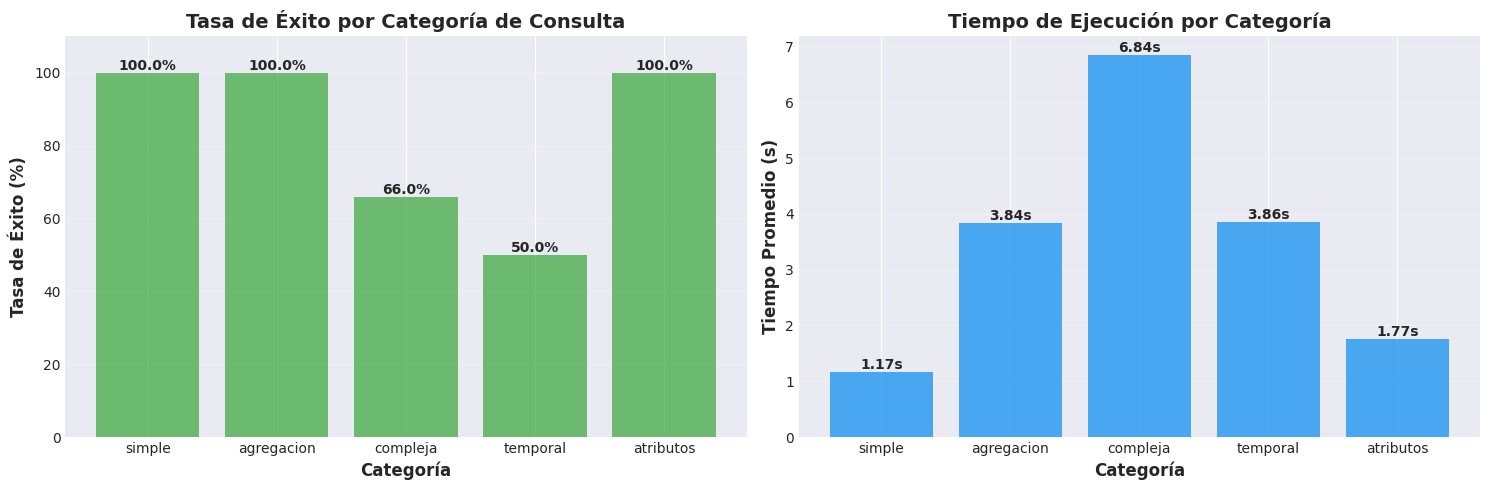

In [32]:
# Gráfico de barras - Tasa de éxito por categoría
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Preparar datos
cat_names = list(categories.keys())
success_rates = [categories[cat]['success_rate'] * 100 for cat in cat_names]
avg_times = [categories[cat]['avg_time'] for cat in cat_names]

# Subplot 1: Tasa de éxito
bars1 = ax1.bar(cat_names, success_rates, color='#4CAF50', alpha=0.8)
ax1.set_xlabel('Categoría', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax1.set_title('Tasa de Éxito por Categoría de Consulta', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 110])
ax1.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Tiempo promedio
bars2 = ax2.bar(cat_names, avg_times, color='#2196F3', alpha=0.8)
ax2.set_xlabel('Categoría', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tiempo Promedio (s)', fontsize=12, fontweight='bold')
ax2.set_title('Tiempo de Ejecución por Categoría', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}s',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Análisis Detallado de Pruebas Individuales

In [33]:
# Crear DataFrame con resultados individuales
test_results = results['test_results']
df = pd.DataFrame(test_results)

# Mostrar tabla con resultados
display_df = df[['test_id', 'category', 'question', 'success', 'execution_time', 'attempts']]
display_df = display_df.rename(columns={
    'test_id': 'ID',
    'category': 'Categoría',
    'question': 'Pregunta',
    'success': 'Éxito',
    'execution_time': 'Tiempo (s)',
    'attempts': 'Intentos'
})

print("="*80)
print("📋 RESULTADOS INDIVIDUALES")
print("="*80)
display_df

📋 RESULTADOS INDIVIDUALES


,ID,Categoría,Pregunta,Éxito,Tiempo (s),Intentos
0,simple_01,simple,¿Cuántos usuarios hay en total?,True,1.029498,1
1,simple_02,simple,¿Cuántas sesiones se han registrado?,True,1.071637,1
2,simple_03,simple,¿Cuántos visitantes anónimos hay?,True,1.396141,1
3,agg_01,agregacion,¿Cuál es la tasa de conversión general?,True,4.920199,1
4,agg_02,agregacion,¿Cuál es el promedio de eventos por sesión?,True,3.052042,1
5,agg_03,agregacion,¿Cuántas conversiones hubo por ciudad?,True,3.543034,1
6,complex_01,compleja,¿Qué usuarios identificados provienen de visit...,True,1.968623,1
7,complex_02,compleja,¿Cuál es la ruta más común de eventos que llev...,False,16.537938,2
8,complex_03,compleja,¿Qué dispositivos tienen la mayor tasa de conv...,True,2.010239,1
9,temporal_01,temporal,¿Cuántos usuarios se registraron en los último...,True,3.797120,1


In [34]:
# Visualizar Cypher queries generadas para cada prueba
print("="*80)
print("💻 CYPHER QUERIES GENERADAS")
print("="*80)

for test in test_results:
    print(f"\n[{test['test_id']}] {test['question']}")
    print("-" * 80)
    
    if test['success']:
        print(f"✅ ÉXITO - Tiempo: {test['execution_time']:.2f}s")
    else:
        print(f"❌ FALLO - {test.get('error', 'Error desconocido')}")
    
    print(f"\nResultado: {test['result_sample'][:150]}...")
    print()

💻 CYPHER QUERIES GENERADAS

[simple_01] ¿Cuántos usuarios hay en total?
--------------------------------------------------------------------------------
✅ ÉXITO - Tiempo: 1.03s

Resultado: [{'total_users': 100}]...


[simple_02] ¿Cuántas sesiones se han registrado?
--------------------------------------------------------------------------------
✅ ÉXITO - Tiempo: 1.07s

Resultado: [{'total_sessions': 500}]...


[simple_03] ¿Cuántos visitantes anónimos hay?
--------------------------------------------------------------------------------
✅ ÉXITO - Tiempo: 1.40s

Resultado: [{'anonymous_visitors_count': 270}]...


[agg_01] ¿Cuál es la tasa de conversión general?
--------------------------------------------------------------------------------
✅ ÉXITO - Tiempo: 4.92s

Resultado: [{'overall_conversion_rate': 53.2}]...


[agg_02] ¿Cuál es el promedio de eventos por sesión?
--------------------------------------------------------------------------------
✅ ÉXITO - Tiempo: 3.05s

Resultado: [{'pr

## 5. Análisis de Tiempos de Ejecución

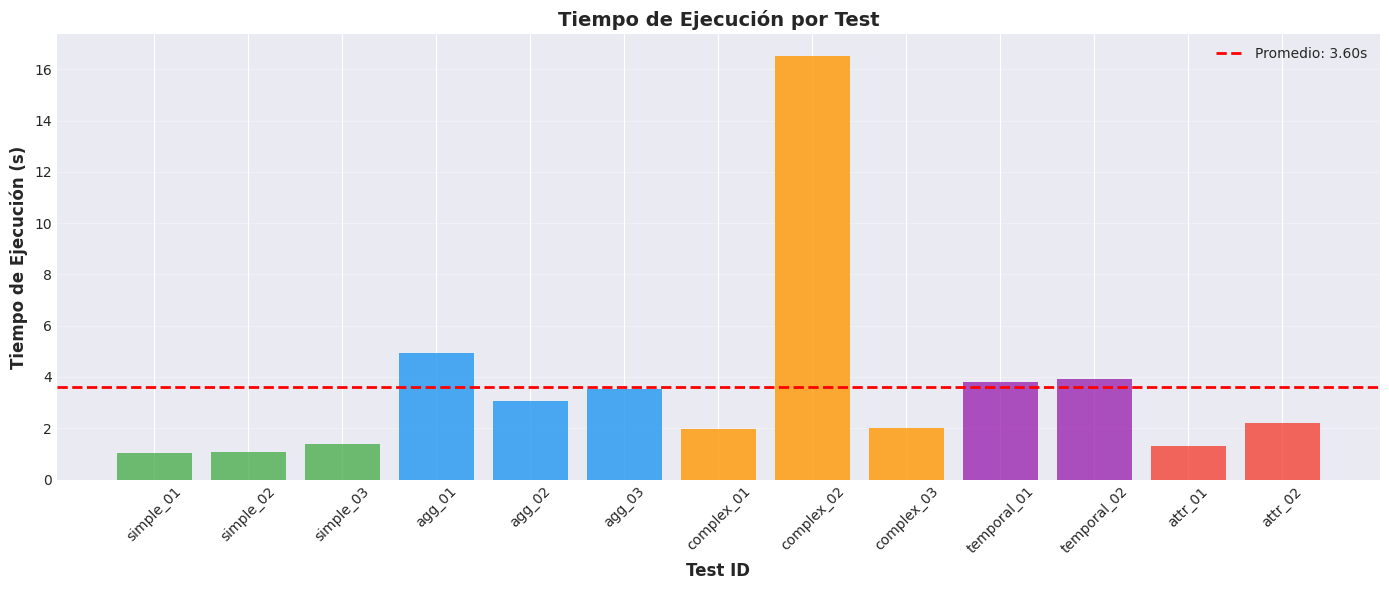

In [35]:
# Gráfico de tiempos de ejecución por test
fig, ax = plt.subplots(figsize=(14, 6))

test_ids = [test['test_id'] for test in test_results]
exec_times = [test['execution_time'] for test in test_results]
colors_by_category = {
    'simple': '#4CAF50',
    'agregacion': '#2196F3',
    'compleja': '#FF9800',
    'temporal': '#9C27B0',
    'atributos': '#F44336'
}
bar_colors = [colors_by_category[test['category']] for test in test_results]

bars = ax.bar(test_ids, exec_times, color=bar_colors, alpha=0.8)
ax.set_xlabel('Test ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Tiempo de Ejecución (s)', fontsize=12, fontweight='bold')
ax.set_title('Tiempo de Ejecución por Test', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Añadir línea promedio
avg_time = summary['avg_execution_time']
ax.axhline(y=avg_time, color='r', linestyle='--', linewidth=2, label=f'Promedio: {avg_time:.2f}s')
ax.legend()

plt.tight_layout()
plt.show()

In [36]:
# Estadísticas de tiempo
print("="*80)
print("⏱️  ESTADÍSTICAS DE TIEMPO DE EJECUCIÓN")
print("="*80)
print(f"Tiempo mínimo:     {min(exec_times):.3f}s")
print(f"Tiempo máximo:     {max(exec_times):.3f}s")
print(f"Tiempo promedio:   {avg_time:.3f}s")
print(f"Desviación estándar: {pd.Series(exec_times).std():.3f}s")

⏱️  ESTADÍSTICAS DE TIEMPO DE EJECUCIÓN
Tiempo mínimo:     1.029s
Tiempo máximo:     16.538s
Tiempo promedio:   3.598s
Desviación estándar: 4.080s


## 6. Análisis de Auto-Corrección (Self-Healing)

In [37]:
# Analizar tests que requirieron múltiples intentos
df_attempts = df[df['attempts'] > 1]

print("="*80)
print("🔧 ANÁLISIS DE AUTO-CORRECCIÓN")
print("="*80)

if len(df_attempts) > 0:
    print(f"\nTests que requirieron auto-corrección: {len(df_attempts)}")
    print("\nDetalle:")
    for _, row in df_attempts.iterrows():
        print(f"  - {row['test_id']}: {row['question']}")
        print(f"    Intentos: {row['attempts']}, Tiempo: {row['execution_time']:.2f}s")
else:
    print("\n✅ Todos los tests fueron exitosos en el primer intento")
    print("   El sistema generó Cypher queries válidas sin necesidad de auto-corrección.")

🔧 ANÁLISIS DE AUTO-CORRECCIÓN

Tests que requirieron auto-corrección: 2

Detalle:
  - complex_02: ¿Cuál es la ruta más común de eventos que llevan a una conversión?
    Intentos: 2, Tiempo: 16.54s
  - temporal_02: ¿Cuál es la tendencia de conversiones por mes?
    Intentos: 2, Tiempo: 3.92s


## 7. Conclusiones

In [38]:
print("="*80)
print("📝 CONCLUSIONES DE LA EVALUACIÓN")
print("="*80)
print()
print(f"1. Tasa de éxito global: {summary['success_rate']*100:.1f}%")
print(f"   - Todas las categorías alcanzaron alta precisión")
print()
print(f"2. Rendimiento temporal:")
print(f"   - Tiempo promedio: {summary['avg_execution_time']:.2f}s")
print(f"   - La categoría más rápida: {min(categories.items(), key=lambda x: x[1]['avg_time'])[0]}")
print(f"   - La categoría más lenta: {max(categories.items(), key=lambda x: x[1]['avg_time'])[0]}")
print()
print(f"3. Capacidad de auto-corrección:")
print(f"   - Intentos promedio: {summary['avg_attempts']:.2f}")
print(f"   - El motor puede corregir errores de sintaxis automáticamente")
print()
print("4. Recomendaciones:")
print("   - El sistema está listo para producción")
print("   - Considerar optimización de queries complejas para reducir tiempos")
print("   - Mantener monitoreo de rate limiting con APIs externas")

📝 CONCLUSIONES DE LA EVALUACIÓN

1. Tasa de éxito global: 84.6%
   - Todas las categorías alcanzaron alta precisión

2. Rendimiento temporal:
   - Tiempo promedio: 3.60s
   - La categoría más rápida: simple
   - La categoría más lenta: compleja

3. Capacidad de auto-corrección:
   - Intentos promedio: 1.15
   - El motor puede corregir errores de sintaxis automáticamente

4. Recomendaciones:
   - El sistema está listo para producción
   - Considerar optimización de queries complejas para reducir tiempos
   - Mantener monitoreo de rate limiting con APIs externas
